In [ ]:
pip list

Package                                  Version
---------------------------------------- ------------------
absl-py                                  1.4.0
accelerate                               1.14.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.2
aiohttp                                  3.14.1
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.12.0
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                          

In [ ]:
script source: https://github.com/futureomics/Machine-Learning-Regression-Modeling-for-Gene-Expression-Predicting-logFC-or-B-

In [ ]:

!pip install pandas scikit-learn numpy

Random Forest Regressor Results (Target = logFC )
MSE: 0.00039908992201262547
R2 Score: 0.8701437909182757

Linear Regression Results (Target = logFC )
MSE: 0.0010426407443733922
R2 Score: 0.6607446917835407


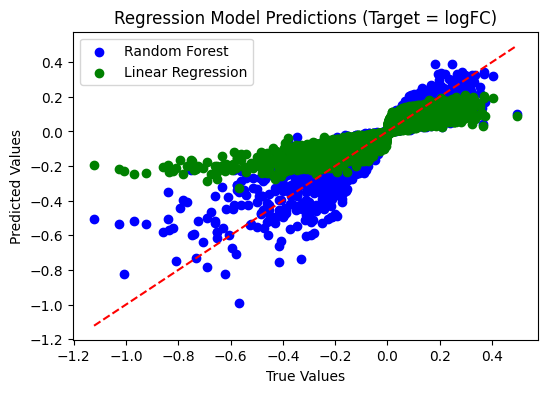

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# --- Step 1: Load data ---
data = pd.read_csv("/content/MasterDEGmerge.csv")  # Save your data in CSV first

# === Step 2: Choose Target Variable ===
# Options: "logFC" or "B"
target = "logFC"   # <-- change to "B" if you want to predict B instead

X = data[['AveExpr', 't', 'P.Value', 'adj.P.Val']]
y = data[target]

# === Step 3: Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# === Step 4A: Random Forest Regressor ===
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Regressor Results (Target =", target, ")")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

# === Step 4B: Linear Regression (for comparison) ===
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\nLinear Regression Results (Target =", target, ")")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

# === Step 5: Visualization ===
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_rf, label="Random Forest", color="blue")
plt.scatter(y_test, y_pred_lr, label="Linear Regression", color="green")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')  # y=x line
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"Regression Model Predictions (Target = {target})")
plt.legend()
plt.show()

--- Model Evaluation (Target = logFC) ---

Linear Regression:
  MSE: 0.0010
  R2 Score: 0.6607

Random Forest:
  MSE: 0.0004
  R2 Score: 0.8701

Decision Tree:
  MSE: 0.0008
  R2 Score: 0.7448

Gradient Boosting:
  MSE: 0.0004
  R2 Score: 0.8609

KNN Regressor:
  MSE: 0.0004
  R2 Score: 0.8543


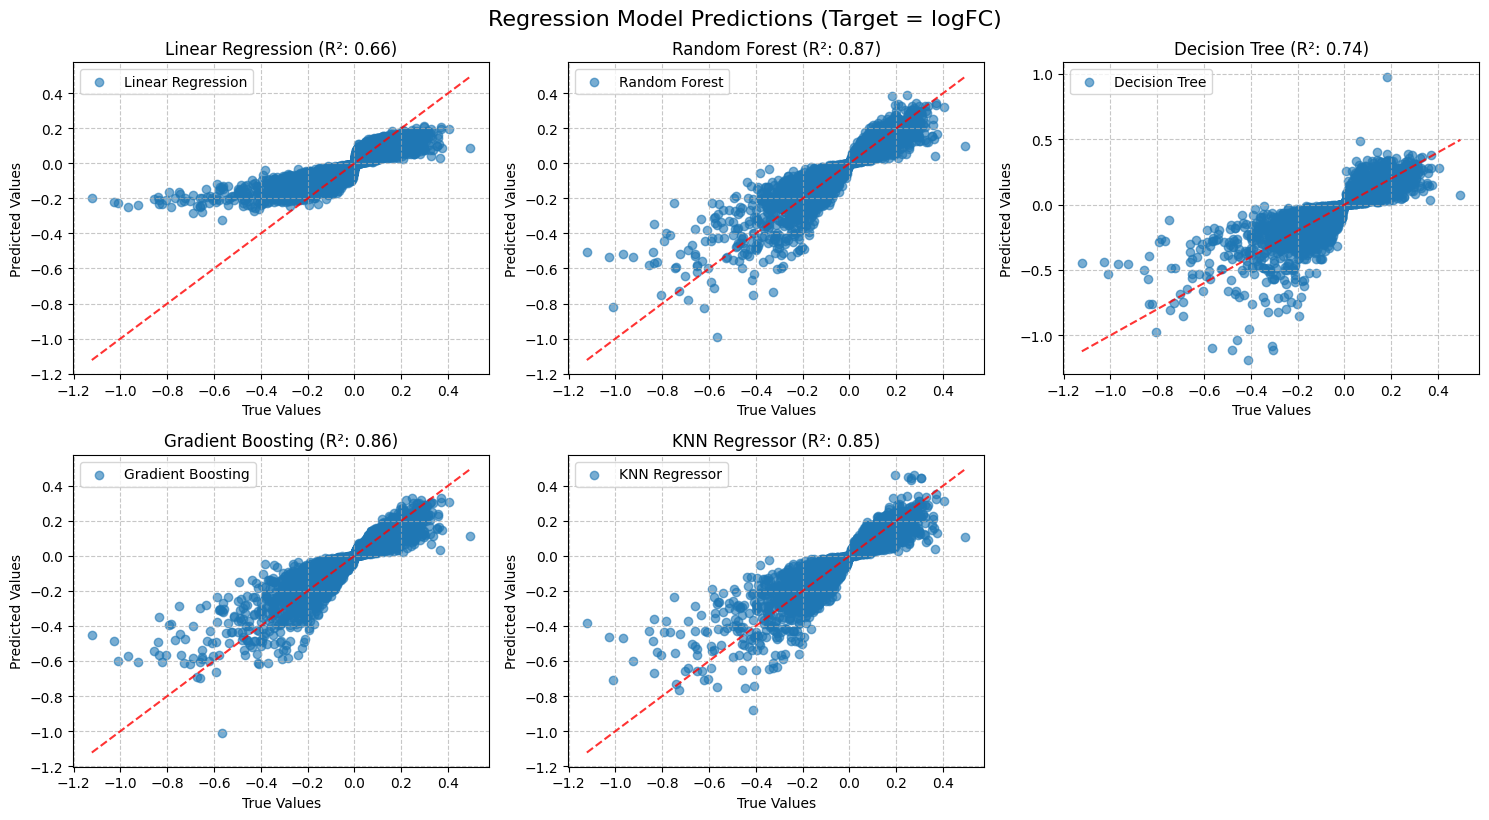

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.cm as cm

# --- Step 1: Load data ---
data = pd.read_csv("/content/MasterDEGmerge.csv")  # Save your data in CSV first

# === Step 2: Choose Target Variable ===
# Options: "logFC" or "B"
target = "logFC"   # <-- change to "B" if you want to predict B instead

X = data[['AveExpr', 't', 'P.Value', 'adj.P.Val']]
y = data[target]

# === Step 3: Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# === Define Models ===
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5) # Default n_neighbors=5
}

results = {}
predictions = {} # Store predictions for plotting

print(f"--- Model Evaluation (Target = {target}) ---")

# === Train and Evaluate Each Model ===
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MSE": mse, "R2": r2}
    predictions[name] = y_pred
    print(f"\n{name}:")
    print(f"  MSE: {mse:.4f}")
    print(f"  R2 Score: {r2:.4f}")

# === Visualization (True vs Predicted for All Models in One Plot) ===
plt.figure(figsize=(10, 8))

# Generate a color map for different models
colors = cm.get_cmap('tab10', len(models))

i = 0
for name, y_pred in predictions.items():
    plt.scatter(y_test, y_pred, alpha=0.6, label=f"{name} (R²: {results[name]['R2']:.2f})", color=colors(i))
    i += 1

# Add the y=x line for ideal prediction
min_val = min(y_test.min(), min([pred.min() for pred in predictions.values()]))
max_val = max(y_test.max(), max([pred.max() for pred in predictions.values()]))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Ideal Prediction (y=x)')

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"Regression Model Predictions (Target = {target})")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Linear Regression → MSE: 0.0010, R²: 0.6607
Random Forest → MSE: 0.0004, R²: 0.8701
Decision Tree → MSE: 0.0008, R²: 0.7448
Gradient Boosting → MSE: 0.0004, R²: 0.8609
KNN Regressor → MSE: 0.0005, R²: 0.8369


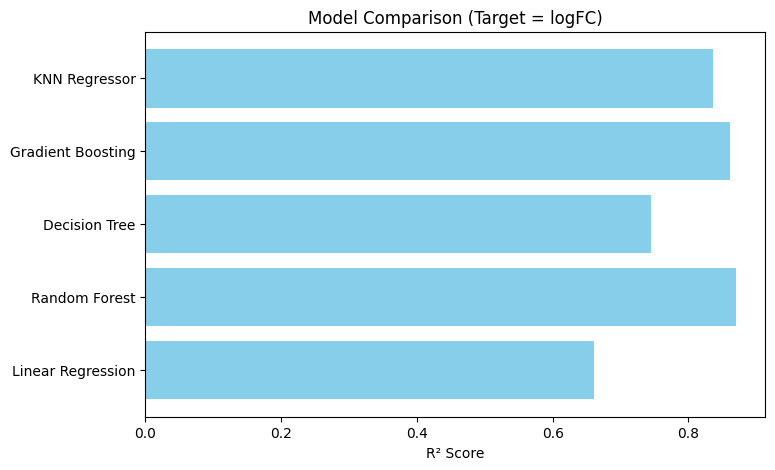

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor



# === Step 6: Define Models ===
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=3)
}

results = {}

# === Step 7: Train and Evaluate Each Model ===
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MSE": mse, "R2": r2}
    print(f"{name} → MSE: {mse:.4f}, R²: {r2:.4f}")

# === Step 8: Visualization of R² scores ===
plt.figure(figsize=(8,5))
r2_scores = [results[m]["R2"] for m in results]
plt.barh(list(results.keys()), r2_scores, color="skyblue")
plt.xlabel("R² Score")
plt.title(f"Model Comparison (Target = {target})")
plt.show()

### Top 50 Genes Based on 'predicted logFC' values through Random Forest

To identify the top 50 genes with the most significant 't' values, we will sort the original dataset by the absolute value of the 't' statistic in descending order. This highlights genes with the strongest differential expression.

In [ ]:
# Get the trained Random Forest model from the comprehensive evaluation in cell 7d97A8vFiwSy
rf_model_for_importances = models["Random Forest"]

# Get feature importances
feature_importances = rf_model_for_importances.feature_importances_

# Get feature names from the X DataFrame
feature_names = X.columns

# Create a DataFrame for better visualization and sort by importance
features_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Random Forest Feature Importances (for predicting logFC):")
display(features_df)

Random Forest Feature Importances (for predicting logFC):


,Feature,Importance
0,t,0.631236
1,AveExpr,0.205468
2,adj.P.Val,0.089760
3,P.Value,0.073536


Top50 gene prediction

In [ ]:
import pandas as pd

# Get the trained Random Forest model from the comprehensive evaluation in cell 7d97A8vFiwSy
rf_model_for_prediction = models["Random Forest"]

# Make predictions for all genes in the original data
# We need to use the original X (all features for all genes) to predict
X_full_data = data[['AveExpr', 't', 'P.Value', 'adj.P.Val']]
rf_predictions_all_genes = rf_model_for_prediction.predict(X_full_data)

# Add the predictions to a temporary DataFrame for sorting
predicted_logFC_df = data.copy()
predicted_logFC_df['predicted_logFC_rf'] = rf_predictions_all_genes

# --- Simply fetch top 50 unique genes based on the highest absolute predicted_logFC_rf ---
top_50_genes_rf_prediction_unique = (
    predicted_logFC_df.sort_values(by='predicted_logFC_rf', key=abs, ascending=False)['Symbol']
    .drop_duplicates()
    .head(50)
    .tolist()
)

print(f"Identified {len(top_50_genes_rf_prediction_unique)} unique gene symbols based on absolute Random Forest predicted logFC.")

# --- Filter the original predicted_logFC_df to get ALL entries for these 50 unique genes ---
# This DataFrame will contain multiple rows for a gene if it appeared multiple times in the original 'data'
# but only for the top 50 unique gene symbols identified above.
top_50_genes_all_entries_df = predicted_logFC_df[
    predicted_logFC_df['Symbol'].isin(top_50_genes_rf_prediction_unique)
]

# No additional sorting by Symbol or predicted_logFC_rf as requested.
# The order will reflect the original DataFrame's order for these filtered genes.

print(f"\nDetailed data for the Top {len(top_50_genes_rf_prediction_unique)} Unique Genes (including all group-wise entries):")
print(f"Total rows in this detailed output: {len(top_50_genes_all_entries_df)}")
display(top_50_genes_all_entries_df.head(20))

# Assign the final DataFrame to the name 'top_50_unique_genes_df'
# so the subsequent export cell and other cells (if any) can pick it up correctly.
top_50_unique_genes_df = top_50_genes_all_entries_df

Identified 50 unique gene symbols based on absolute Random Forest predicted logFC.

Detailed data for the Top 50 Unique Genes (including all group-wise entries):
Total rows in this detailed output: 417


,Symbol,logFC,AveExpr,t,P.Value,adj.P.Val,B,predicted_logFC_rf
0,MRPL51,-0.566251,9.038266,-12.669819,2.446890e-30,9.377230e-26,58.093864,-0.989020
1,NDUFA1,-1.096440,10.874279,-12.488075,1.168850e-29,2.239700e-25,56.558419,-1.023380
2,SEM1,-0.993525,8.985867,-11.577542,2.597970e-26,3.318730e-22,48.992911,-0.946151
3,NDUFS5,-0.920081,9.325332,-11.524389,4.044680e-26,3.875110e-22,48.558427,-0.878378
4,RPL22,-0.968918,10.937154,-11.263938,3.495170e-25,2.678910e-21,46.441943,-0.928934
6,RPL36AL,-0.690057,12.310404,-10.981494,3.535820e-24,1.935760e-20,44.171215,-0.780454
8,ATP5ME,-0.743725,10.512184,-10.734481,2.617290e-23,1.029060e-19,42.207395,-0.688461
9,HSPE1,-0.758510,8.834092,-10.720561,2.927970e-23,1.029060e-19,42.097362,-0.735825
16,ENY2,-0.693917,8.499128,-10.391752,4.058940e-22,8.186880e-19,39.518730,-0.615125
18,ATP6V1E1,-0.414536,10.922204,-10.136365,3.041400e-21,5.297990e-18,37.544088,-0.509486


In [ ]:
csv_file_name = 'top_50_unique_genes.csv'
top_50_unique_genes_df.to_csv(csv_file_name, index=False)
print(f"DataFrame exported to {csv_file_name}")

DataFrame exported to top_50_unique_genes.csv


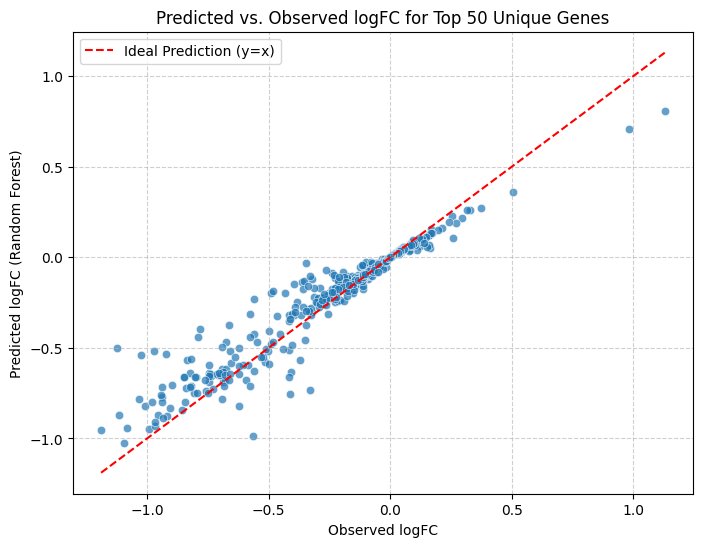

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(x='logFC', y='predicted_logFC_rf', data=top_50_unique_genes_df, alpha=0.7)

# Add a y=x line for ideal prediction
min_val = min(top_50_unique_genes_df['logFC'].min(), top_50_unique_genes_df['predicted_logFC_rf'].min())
max_val = max(top_50_unique_genes_df['logFC'].max(), top_50_unique_genes_df['predicted_logFC_rf'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Prediction (y=x)')

plt.title('Predicted vs. Observed logFC for Top 50 Unique Genes')
plt.xlabel('Observed logFC')
plt.ylabel('Predicted logFC (Random Forest)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import pandas as pd

# Assuming 'models' dictionary and 'data' DataFrame are available from previous cells

# Ensure X_full_data is defined, consistent with previous gene prediction cells
X_full_data = data[['AveExpr', 't', 'P.Value', 'adj.P.Val']]

# --- KNN Regressor Prediction ---
print("\n--- Top 50 Genes based on KNN Regressor Predictions ---")
rf_model_for_prediction = models["KNN Regressor"]

# Make predictions for all genes in the original data
knn_predictions_all_genes = rf_model_for_prediction.predict(X_full_data)

# Add the predictions to a temporary DataFrame for sorting
predicted_logFC_df_knn = data.copy()
predicted_logFC_df_knn['predicted_logFC_knn'] = knn_predictions_all_genes

# Simply fetch top 50 unique genes based on the highest absolute predicted_logFC_knn
top_50_genes_knn_prediction_unique = (
    predicted_logFC_df_knn.sort_values(by='predicted_logFC_knn', key=abs, ascending=False)['Symbol']
    .drop_duplicates()
    .head(50)
    .tolist()
)

print(f"Identified {len(top_50_genes_knn_prediction_unique)} unique gene symbols based on absolute KNN predicted logFC.")

# Filter the original predicted_logFC_df_knn to get ALL entries for these 50 unique genes
top_50_genes_knn_all_entries_df = predicted_logFC_df_knn[
    predicted_logFC_df_knn['Symbol'].isin(top_50_genes_knn_prediction_unique)
]

print(f"\nDetailed data for the Top {len(top_50_genes_knn_prediction_unique)} Unique Genes (KNN, including all group-wise entries):")
print(f"Total rows in this detailed output: {len(top_50_genes_knn_all_entries_df)}")
display(top_50_genes_knn_all_entries_df.head(20))

# --- Gradient Boosting Regressor Prediction ---
print("\n--- Top 50 Genes based on Gradient Boosting Regressor Predictions ---")
rf_model_for_prediction = models["Gradient Boosting"]

# Make predictions for all genes in the original data
gb_predictions_all_genes = rf_model_for_prediction.predict(X_full_data)

# Add the predictions to a temporary DataFrame for sorting
predicted_logFC_df_gb = data.copy()
predicted_logFC_df_gb['predicted_logFC_gb'] = gb_predictions_all_genes

# Simply fetch top 50 unique genes based on the highest absolute predicted_logFC_gb
top_50_genes_gb_prediction_unique = (
    predicted_logFC_df_gb.sort_values(by='predicted_logFC_gb', key=abs, ascending=False)['Symbol']
    .drop_duplicates()
    .head(50)
    .tolist()
)

print(f"Identified {len(top_50_genes_gb_prediction_unique)} unique gene symbols based on absolute Gradient Boosting predicted logFC.")

# Filter the original predicted_logFC_df_gb to get ALL entries for these 50 unique genes
top_50_genes_gb_all_entries_df = predicted_logFC_df_gb[
    predicted_logFC_df_gb['Symbol'].isin(top_50_genes_gb_prediction_unique)
]

print(f"\nDetailed data for the Top {len(top_50_genes_gb_prediction_unique)} Unique Genes (Gradient Boosting, including all group-wise entries):")
print(f"Total rows in this detailed output: {len(top_50_genes_gb_all_entries_df)}")
display(top_50_genes_gb_all_entries_df.head(20))


--- Top 50 Genes based on KNN Regressor Predictions ---
Identified 50 unique gene symbols based on absolute KNN predicted logFC.

Detailed data for the Top 50 Unique Genes (KNN, including all group-wise entries):
Total rows in this detailed output: 432


,Symbol,logFC,AveExpr,t,P.Value,adj.P.Val,B,predicted_logFC_knn
0,MRPL51,-0.566251,9.038266,-12.669819,2.446890e-30,9.377230e-26,58.093864,-0.748195
1,NDUFA1,-1.096440,10.874279,-12.488075,1.168850e-29,2.239700e-25,56.558419,-0.944538
2,SEM1,-0.993525,8.985867,-11.577542,2.597970e-26,3.318730e-22,48.992911,-0.680609
3,NDUFS5,-0.920081,9.325332,-11.524389,4.044680e-26,3.875110e-22,48.558427,-0.708355
4,RPL22,-0.968918,10.937154,-11.263938,3.495170e-25,2.678910e-21,46.441943,-0.772188
5,ING3,-0.388628,8.241637,-11.178364,7.065880e-25,4.513090e-21,45.751208,-0.643140
6,RPL36AL,-0.690057,12.310404,-10.981494,3.535820e-24,1.935760e-20,44.171215,-0.638628
7,CETN2,-0.342302,9.527988,-10.794583,1.611280e-23,7.718650e-20,42.683266,-0.637114
8,ATP5ME,-0.743725,10.512184,-10.734481,2.617290e-23,1.029060e-19,42.207395,-0.702129
9,HSPE1,-0.758510,8.834092,-10.720561,2.927970e-23,1.029060e-19,42.097362,-0.512742



--- Top 50 Genes based on Gradient Boosting Regressor Predictions ---
Identified 50 unique gene symbols based on absolute Gradient Boosting predicted logFC.

Detailed data for the Top 50 Unique Genes (Gradient Boosting, including all group-wise entries):
Total rows in this detailed output: 417


,Symbol,logFC,AveExpr,t,P.Value,adj.P.Val,B,predicted_logFC_gb
0,MRPL51,-0.566251,9.038266,-12.669819,2.446890e-30,9.377230e-26,58.093864,-1.009257
1,NDUFA1,-1.096440,10.874279,-12.488075,1.168850e-29,2.239700e-25,56.558419,-1.035065
2,SEM1,-0.993525,8.985867,-11.577542,2.597970e-26,3.318730e-22,48.992911,-1.007852
3,NDUFS5,-0.920081,9.325332,-11.524389,4.044680e-26,3.875110e-22,48.558427,-0.904537
4,RPL22,-0.968918,10.937154,-11.263938,3.495170e-25,2.678910e-21,46.441943,-0.923770
8,ATP5ME,-0.743725,10.512184,-10.734481,2.617290e-23,1.029060e-19,42.207395,-0.648674
9,HSPE1,-0.758510,8.834092,-10.720561,2.927970e-23,1.029060e-19,42.097362,-0.687033
10,COX17,-0.527357,9.610981,-10.719473,2.953760e-23,1.029060e-19,42.088762,-0.578460
12,RPS25,-0.650521,13.645632,-10.589421,8.395320e-23,2.474880e-19,41.064158,-0.575272
15,TBCA,-0.637320,9.966149,-10.431472,2.960740e-22,6.426500e-19,39.828102,-0.595721


In [ ]:
csv_file_name_knn = 'top_50_unique_genes_knn.csv'
top_50_genes_knn_all_entries_df.to_csv(csv_file_name_knn, index=False)
print(f"DataFrame for KNN top 50 genes exported to {csv_file_name_knn}")

csv_file_name_gb = 'top_50_unique_genes_gb.csv'
top_50_genes_gb_all_entries_df.to_csv(csv_file_name_gb, index=False)
print(f"DataFrame for Gradient Boosting top 50 genes exported to {csv_file_name_gb}")

DataFrame for KNN top 50 genes exported to top_50_unique_genes_knn.csv
DataFrame for Gradient Boosting top 50 genes exported to top_50_unique_genes_gb.csv


In [ ]:
!pip install stringdb


### Using STRING DB API Directly with `requests`

Since dedicated client libraries have been problematic, we will now directly query the STRING DB API using Python's `requests` library. This involves:

1.  **Defining API Endpoints**: Identifying the correct URLs for gene mapping and interaction retrieval.
2.  **Constructing Payloads**: Preparing the data to be sent to the API, typically in JSON format.
3.  **Sending Requests**: Using `requests.post` or `requests.get` to communicate with the API.
4.  **Parsing Responses**: Handling the JSON data returned by the API.

We will use the following endpoints:
*   **[STRING IDs Mapping](https://string-db.org/api/json/get_string_ids)**: To map gene symbols to STRING identifiers.
*   **[Protein-Protein Interactions](https://string-db.org/api/json/network)**: To retrieve interaction data for a given set of STRING identifiers.

Mapping gene symbols to STRING IDs...
Successfully mapped 48 out of 50 genes to STRING IDs.
Retrieving protein-protein interactions...
PPI network created with 46 nodes and 248 edges.
PPI network visualization saved as 'ppi_network_high_res.png'


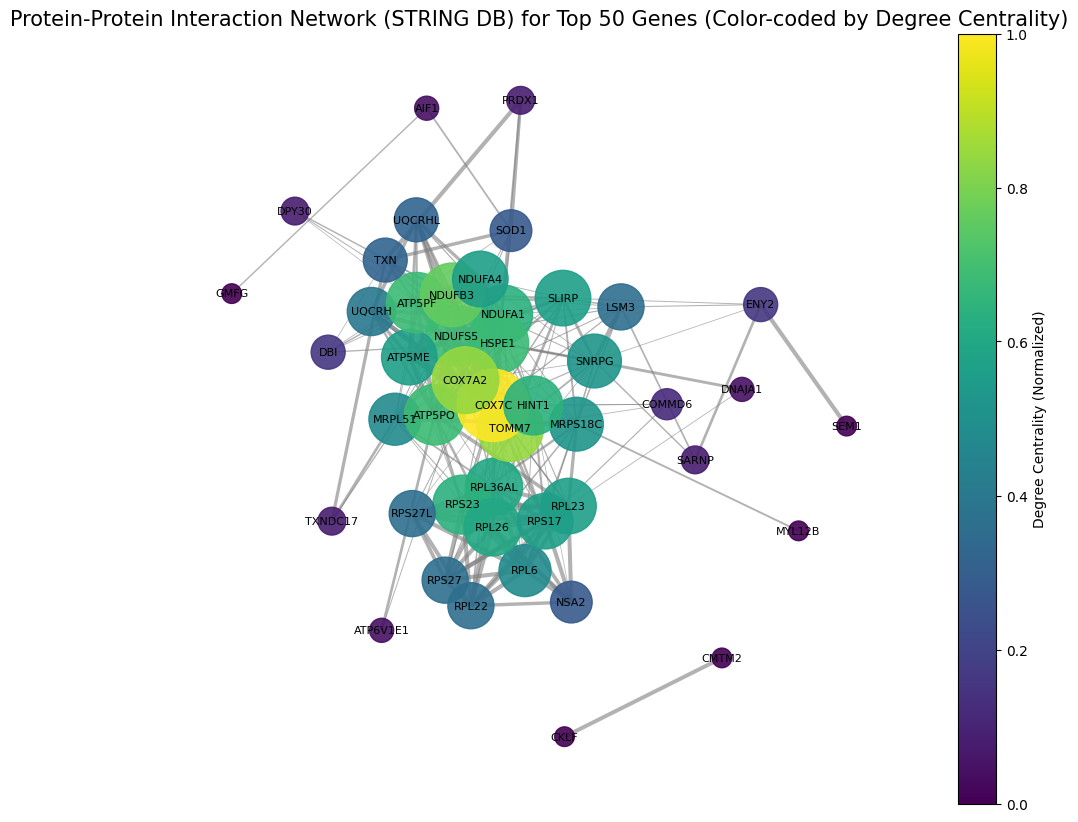

In [ ]:
import requests
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm # Import colormap for coloring

# --- Configuration ---
string_api_url = "https://string-db.org/api"
output_format = "json"
species_id = 9606 # Homo sapiens
required_score = 400 # Minimum interaction score (0-1000)

# Extract gene symbols from the top_50_unique_genes_df
gene_symbols = top_50_unique_genes_df['Symbol'].unique().tolist()

# --- Step 1: Map gene symbols to STRING IDs ---
print("Mapping gene symbols to STRING IDs...")

method = "get_string_ids"
request_url = "/".join([string_api_url, output_format, method])

params = {
    "identifiers": "\r".join(gene_symbols), # STRING expects identifiers separated by newline or carriage return
    "species": species_id,
    "limit": 1 # Only one best match per gene if multiple are found
}

try:
    response = requests.post(request_url, data=params)
    response.raise_for_status() # Raise an exception for HTTP errors
    mapped_genes_data = response.json()
except requests.exceptions.RequestException as e:
    print(f"Error mapping genes: {e}")
    mapped_genes_data = []

string_ids_to_preferred_name = {}
string_ids = []

for entry in mapped_genes_data:
    if 'stringId' in entry and 'preferredName' in entry:
        string_ids.append(entry['stringId'])
        string_ids_to_preferred_name[entry['stringId']] = entry['preferredName']

print(f"Successfully mapped {len(string_ids)} out of {len(gene_symbols)} genes to STRING IDs.")

# --- Step 2: Retrieve Protein-Protein Interactions (PPI) ---
if not string_ids:
    print("No STRING IDs obtained. Cannot construct PPI network.")
else:
    print("Retrieving protein-protein interactions...")
    method = "network"
    request_url = "/".join([string_api_url, output_format, method])

    params = {
        "identifiers": "\r".join(string_ids), # STRING IDs as identifiers
        "species": species_id,
        "required_score": required_score,
        "add_nodes": 0 # Do not add additional nodes to the network
    }

    try:
        response = requests.post(request_url, data=params)
        response.raise_for_status() # Raise an exception for HTTP errors
        interactions_data = response.json()
    except requests.exceptions.RequestException as e:
        print(f"Error retrieving interactions: {e}")
        interactions_data = []

    # --- Step 3: Create NetworkX graph and Visualize ---
    G = nx.Graph()

    # Add nodes to the graph
    for string_id, preferred_name in string_ids_to_preferred_name.items():
        G.add_node(preferred_name, id=string_id)

    # Add edges to the graph
    for interaction in interactions_data:
        node1_string_id = interaction['stringId_A']
        node2_string_id = interaction['stringId_B']
        score = interaction['score']

        node1_name = string_ids_to_preferred_name.get(node1_string_id)
        node2_name = string_ids_to_preferred_name.get(node2_string_id)

        if node1_name and node2_name:
            G.add_edge(node1_name, node2_name, score=score)

    # Remove isolated nodes (genes that were mapped but have no interactions)
    isolated_nodes = [node for node in G.nodes() if G.degree(node) == 0]
    G.remove_nodes_from(isolated_nodes)

    print(f"PPI network created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

    # Visualize the network
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G, k=0.8, iterations=50) # positions for all nodes

    # Calculate Degree Centrality
    degree_centrality = nx.degree_centrality(G)

    # Normalize centrality values to map to colors
    # If all centrality values are zero (e.g., if G is empty), handle this to prevent division by zero
    if degree_centrality:
        max_centrality = max(degree_centrality.values())
        if max_centrality > 0:
            node_colors = [degree_centrality[node] / max_centrality for node in G.nodes()]
        else:
            node_colors = [0.5] * len(G.nodes()) # Default color if all centralities are zero
    else:
        node_colors = []

    # Draw nodes
    node_size = [G.degree(node) * 100 + 100 for node in G.nodes()] # Size nodes by degree
    # Use a colormap to color nodes based on centrality
    cmap = cm.viridis # You can choose other colormaps like 'plasma', 'magma', 'cividis', 'Greens', etc.
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_colors, cmap=cmap, alpha=0.9)

    # Draw edges with varying thickness based on interaction score
    if G.edges():
        edge_scores = nx.get_edge_attributes(G, 'score').values()
        if edge_scores:
            min_score = min(edge_scores)
            max_score = max(edge_scores)
            if max_score > min_score:
                edge_widths = [(G[u][v]['score'] - min_score) / (max_score - min_score) * 2.5 + 0.5 for u, v in G.edges()]
            else:
                edge_widths = [1 for _ in G.edges()]
            nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6, edge_color='gray')

    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=8)

    plt.title('Protein-Protein Interaction Network (STRING DB) for Top 50 Genes (Color-coded by Degree Centrality)', size=15)
    plt.axis('off')
    plt.colorbar(cm.ScalarMappable(cmap=cmap), ax=plt.gca(), orientation='vertical', label='Degree Centrality (Normalized)')

    # Save the figure as a high-resolution PNG
    plt.savefig('ppi_network_high_res.png', dpi=300, bbox_inches='tight')
    print("PPI network visualization saved as 'ppi_network_high_res.png'")

    plt.show()

Enrichment Analysis

In [ ]:
!pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 10.2 MB/s eta 0:00:00


### GO Term Enrichment Analysis for Top 50 Genes

In [ ]:
import gseapy as gp
import pandas as pd

# Extract the unique gene symbols from your top_50_unique_genes_df
gene_list = top_50_unique_genes_df['Symbol'].unique().tolist()

print(f"Performing GO enrichment for {len(gene_list)} genes.")

# Perform Enrichr analysis for GO Biological Process, Molecular Function, and Cellular Component
enr = gp.enrichr(gene_list=gene_list,
                 gene_sets=['GO_Biological_Process_2023', 'GO_Molecular_Function_2023', 'GO_Cellular_Component_2023'],
                 organism='human', # corrected to 'human'
                 outdir=None, # do not write to file
                 cutoff=0.05 # P-value cutoff
                )

# Display the top results for each gene set
print("\n--- Top GO Biological Process Terms ---")
display(enr.results[enr.results['Gene_set'] == 'GO_Biological_Process_2023'].head(10))

print("\n--- Top GO Molecular Function Terms ---")
display(enr.results[enr.results['Gene_set'] == 'GO_Molecular_Function_2023'].head(10))

print("\n--- Top GO Cellular Component Terms ---")
display(enr.results[enr.results['Gene_set'] == 'GO_Cellular_Component_2023'].head(10))

# You can also access the full results DataFrame
# display(enr.results.head())

Performing GO enrichment for 50 genes.

--- Top GO Biological Process Terms ---


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Peptide Biosynthetic Process (GO:0043043),9/158,1.809829e-10,3.253012e-08,0,0,29.171550,654.394253,RPS17;MRPL51;RPS27;RPL36AL;RPL22;RPL26;RPL6;MR...
1,GO_Biological_Process_2023,Oxidative Phosphorylation (GO:0006119),7/63,1.959646e-10,3.253012e-08,0,0,57.831395,1292.710221,ATP5PF;NDUFS5;NDUFB3;NDUFA1;ATP5PO;UQCRH;ATP5ME
2,GO_Biological_Process_2023,Aerobic Electron Transport Chain (GO:0019646),7/68,3.401527e-10,3.478013e-08,0,0,53.077774,1157.181795,NDUFS5;NDUFB3;NDUFA1;COX7A2;COX7C;UQCRH;UQCRHL
3,GO_Biological_Process_2023,Mitochondrial ATP Synthesis Coupled Electron T...,7/70,4.190377e-10,3.478013e-08,0,0,51.387597,1109.615475,NDUFS5;NDUFB3;NDUFA1;COX7A2;COX7C;UQCRH;UQCRHL
4,GO_Biological_Process_2023,Macromolecule Biosynthetic Process (GO:0009059),9/183,6.693272e-10,4.444333e-08,0,0,24.948696,527.034927,RPS17;MRPL51;RPS27;RPL36AL;RPL22;RPL26;RPL6;MR...
5,GO_Biological_Process_2023,Gene Expression (GO:0010467),10/296,2.638193e-09,1.459800e-07,0,0,17.188811,339.533538,RPS17;MRPL51;RPS27;RPL36AL;SARNP;RPL22;RPL26;R...
6,GO_Biological_Process_2023,Cytoplasmic Translation (GO:0002181),7/93,3.171126e-09,1.504020e-07,0,0,37.600865,735.818071,RPS17;RPS27;RPL36AL;RPL22;RPL26;RPL6;RPS23
7,GO_Biological_Process_2023,Proton Motive Force-Driven Mitochondrial ATP S...,6/53,3.757720e-09,1.559454e-07,0,0,57.745648,1120.234004,ATP5PF;NDUFS5;NDUFB3;NDUFA1;ATP5PO;ATP5ME
8,GO_Biological_Process_2023,Translation (GO:0006412),9/234,5.815074e-09,2.145116e-07,0,0,19.243902,364.918510,RPS17;MRPL51;RPS27;RPL36AL;RPL22;RPL26;RPL6;MR...
9,GO_Biological_Process_2023,Proton Motive Force-Driven ATP Synthesis (GO:0...,6/60,8.087040e-09,2.684897e-07,0,0,50.242424,936.167242,ATP5PF;NDUFS5;NDUFB3;NDUFA1;ATP5PO;ATP5ME



--- Top GO Molecular Function Terms ---


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
332,GO_Molecular_Function_2023,Oxidoreduction-Driven Active Transmembrane Tra...,6/54,4.219469e-09,2.362903e-07,0,0,56.539773,1090.287908,NDUFS5;NDUFB3;NDUFA1;COX7C;UQCRH;UQCRHL
333,GO_Molecular_Function_2023,RNA Binding (GO:0003723),16/1411,1.713907e-07,4.798939e-06,0,0,6.259330,97.516099,RPL22;RPS27L;TXN;HSPE1;RPL6;LSM3;RPS17;NSA2;RP...
334,GO_Molecular_Function_2023,Active Monoatomic Ion Transmembrane Transporte...,3/24,2.867422e-05,5.352522e-04,0,0,60.574468,633.579375,COX7C;UQCRH;UQCRHL
335,GO_Molecular_Function_2023,Proton Transmembrane Transporter Activity (GO:...,3/45,1.937400e-04,2.712360e-03,0,0,30.255319,258.652525,COX7C;UQCRH;UQCRHL
336,GO_Molecular_Function_2023,NADH Dehydrogenase (Ubiquinone) Activity (GO:0...,2/33,3.077847e-03,3.047340e-02,0,0,26.772849,154.841442,NDUFS5;NDUFB3
337,GO_Molecular_Function_2023,NADH Dehydrogenase (Quinone) Activity (GO:0050...,2/34,3.265007e-03,3.047340e-02,0,0,25.934896,148.464136,NDUFS5;NDUFB3
338,GO_Molecular_Function_2023,Protein Phosphatase 2B Binding (GO:0030346),1/5,1.243878e-02,7.798196e-02,0,0,101.765306,446.437935,SOD1
339,GO_Molecular_Function_2023,Arachidonic Acid Binding (GO:0050544),1/6,1.490828e-02,7.798196e-02,0,0,81.408163,342.389562,S100A8
340,GO_Molecular_Function_2023,Icosatetraenoic Acid Binding (GO:0050543),1/6,1.490828e-02,7.798196e-02,0,0,81.408163,342.389562,S100A8
341,GO_Molecular_Function_2023,Icosanoid Binding (GO:0050542),1/7,1.737174e-02,7.798196e-02,0,0,67.836735,274.936211,S100A8



--- Top GO Cellular Component Terms ---


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
388,GO_Cellular_Component_2023,Mitochondrial Inner Membrane (GO:0005743),10/370,2.212104e-08,0.000002,0,0,13.604167,239.797063,ATP5PF;MRPL51;NDUFS5;NDUFB3;NDUFA1;ATP5PO;COX7...
389,GO_Cellular_Component_2023,Organelle Inner Membrane (GO:0019866),10/398,4.395556e-08,0.000002,0,0,12.604381,213.519314,ATP5PF;MRPL51;NDUFS5;NDUFB3;NDUFA1;ATP5PO;COX7...
390,GO_Cellular_Component_2023,Mitochondrial Membrane (GO:0031966),11/540,7.228979e-08,0.000002,0,0,10.354854,170.260551,ATP5PF;MRPL51;NDUFS5;NDUFB3;NDUFA1;ATP5PO;TOMM...
391,GO_Cellular_Component_2023,Ribosome (GO:0005840),5/61,4.256952e-07,0.000009,0,0,39.472222,579.039432,RPS17;RPS27;RPL36AL;RPL6;RPS23
392,GO_Cellular_Component_2023,Cytosolic Small Ribosomal Subunit (GO:0022627),4/41,3.268751e-06,0.000053,0,0,46.799060,591.123728,RPS17;RPS27;RPS27L;RPS23
393,GO_Cellular_Component_2023,Small Ribosomal Subunit (GO:0015935),4/42,3.606194e-06,0.000053,0,0,45.565217,571.062381,RPS17;RPS27;RPS27L;RPS23
394,GO_Cellular_Component_2023,Large Ribosomal Subunit (GO:0015934),4/52,8.563426e-06,0.000094,0,0,36.054348,420.682501,RPL36AL;RPL22;RPL26;RPL6
395,GO_Cellular_Component_2023,Cytosolic Large Ribosomal Subunit (GO:0022625),4/52,8.563426e-06,0.000094,0,0,36.054348,420.682501,RPL36AL;RPL22;RPL26;RPL6
396,GO_Cellular_Component_2023,Proton-Transporting ATP Synthase Complex (GO:0...,3/18,1.168311e-05,0.000103,0,0,84.829787,963.442981,ATP5PF;ATP5PO;ATP5ME
397,GO_Cellular_Component_2023,Mitochondrial Proton-Transporting ATP Synthase...,3/18,1.168311e-05,0.000103,0,0,84.829787,963.442981,ATP5PF;ATP5PO;ATP5ME


### Filtered Genes by Top Enrichment Categories

Below, we extract and display the genes that are part of the most significant Gene Ontology (GO) terms from the enrichment analysis for each category (Biological Process, Molecular Function, and Cellular Component). This helps to identify which of your top 50 genes are driving the observed enrichments.

In [ ]:
import pandas as pd

# Helper function to process and display genes from top terms
def display_genes_from_top_terms(enrichment_results, gene_set_name, num_terms=5):
    print(f"\n--- Genes from Top {num_terms} {gene_set_name} Terms ---")

    # Filter results for the specific gene set
    category_results = enrichment_results[enrichment_results['Gene_set'] == gene_set_name].head(num_terms)

    if category_results.empty:
        print(f"No significant terms found for {gene_set_name} in the top {num_terms}.")
        return

    all_enriched_genes = set()
    gene_to_terms = {}

    for index, row in category_results.iterrows():
        term = row['Term']
        genes_in_term = [g.strip() for g in row['Genes'].split(';')]

        for gene in genes_in_term:
            all_enriched_genes.add(gene)
            if gene not in gene_to_terms:
                gene_to_terms[gene] = []
            gene_to_terms[gene].append(term)

    if not all_enriched_genes:
        print(f"No genes found associated with the top {num_terms} {gene_set_name} terms.")
        return

    # Create a DataFrame for better visualization
    gene_term_df = pd.DataFrame([
        {'Gene': gene, 'Associated Top Terms': '; '.join(terms)}
        for gene, terms in gene_to_terms.items()
    ])
    display(gene_term_df)

# Display genes for each category
display_genes_from_top_terms(enr.results, 'GO_Biological_Process_2023')
display_genes_from_top_terms(enr.results, 'GO_Molecular_Function_2023')
display_genes_from_top_terms(enr.results, 'GO_Cellular_Component_2023')

# Optionally, get a unique list of all genes that appeared in any of the top terms
all_unique_enriched_genes = set()
for gene_set_name in ['GO_Biological_Process_2023', 'GO_Molecular_Function_2023', 'GO_Cellular_Component_2023']:
    category_results = enr.results[enr.results['Gene_set'] == gene_set_name].head(5) # Consider top 5 terms
    for index, row in category_results.iterrows():
        genes_in_term = [g.strip() for g in row['Genes'].split(';')]
        all_unique_enriched_genes.update(genes_in_term)

print(f"\nTotal unique genes found in any of the top enriched terms: {len(all_unique_enriched_genes)}")
print(list(all_unique_enriched_genes))


--- Genes from Top 5 GO_Biological_Process_2023 Terms ---


,Gene,Associated Top Terms
0,RPS17,Peptide Biosynthetic Process (GO:0043043); Mac...
1,MRPL51,Peptide Biosynthetic Process (GO:0043043); Mac...
2,RPS27,Peptide Biosynthetic Process (GO:0043043); Mac...
3,RPL36AL,Peptide Biosynthetic Process (GO:0043043); Mac...
4,RPL22,Peptide Biosynthetic Process (GO:0043043); Mac...
5,RPL26,Peptide Biosynthetic Process (GO:0043043); Mac...
6,RPL6,Peptide Biosynthetic Process (GO:0043043); Mac...
7,MRPS18C,Peptide Biosynthetic Process (GO:0043043); Mac...
8,RPS23,Peptide Biosynthetic Process (GO:0043043); Mac...
9,ATP5PF,Oxidative Phosphorylation (GO:0006119)



--- Genes from Top 5 GO_Molecular_Function_2023 Terms ---


,Gene,Associated Top Terms
0,NDUFS5,Oxidoreduction-Driven Active Transmembrane Tra...
1,NDUFB3,Oxidoreduction-Driven Active Transmembrane Tra...
2,NDUFA1,Oxidoreduction-Driven Active Transmembrane Tra...
3,COX7C,Oxidoreduction-Driven Active Transmembrane Tra...
4,UQCRH,Oxidoreduction-Driven Active Transmembrane Tra...
5,UQCRHL,Oxidoreduction-Driven Active Transmembrane Tra...
6,RPL22,RNA Binding (GO:0003723)
7,RPS27L,RNA Binding (GO:0003723)
8,TXN,RNA Binding (GO:0003723)
9,HSPE1,RNA Binding (GO:0003723)



--- Genes from Top 5 GO_Cellular_Component_2023 Terms ---


,Gene,Associated Top Terms
0,ATP5PF,Mitochondrial Inner Membrane (GO:0005743); Org...
1,MRPL51,Mitochondrial Inner Membrane (GO:0005743); Org...
2,NDUFS5,Mitochondrial Inner Membrane (GO:0005743); Org...
3,NDUFB3,Mitochondrial Inner Membrane (GO:0005743); Org...
4,NDUFA1,Mitochondrial Inner Membrane (GO:0005743); Org...
5,ATP5PO,Mitochondrial Inner Membrane (GO:0005743); Org...
6,COX7C,Mitochondrial Inner Membrane (GO:0005743); Org...
7,UQCRH,Mitochondrial Inner Membrane (GO:0005743); Org...
8,MRPS18C,Mitochondrial Inner Membrane (GO:0005743); Org...
9,ATP5ME,Mitochondrial Inner Membrane (GO:0005743); Org...



Total unique genes found in any of the top enriched terms: 29
['RPS27L', 'PRDX1', 'HSPE1', 'RPL26', 'RPL36AL', 'TXN', 'LSM3', 'MRPL51', 'COX7C', 'NSA2', 'SARNP', 'ATP5ME', 'NDUFA1', 'UQCRH', 'NDUFS5', 'ATP5PF', 'RPS27', 'TOMM7', 'RPS23', 'MRPS18C', 'COX7A2', 'ATP5PO', 'NDUFB3', 'RPL6', 'SNRPG', 'RPS17', 'SLIRP', 'UQCRHL', 'RPL22']


### Visualization of GO Term Enrichment Results

Below are bar charts visualizing the top enriched GO terms for Biological Process, Molecular Function, and Cellular Component, based on their 'Combined Score'.

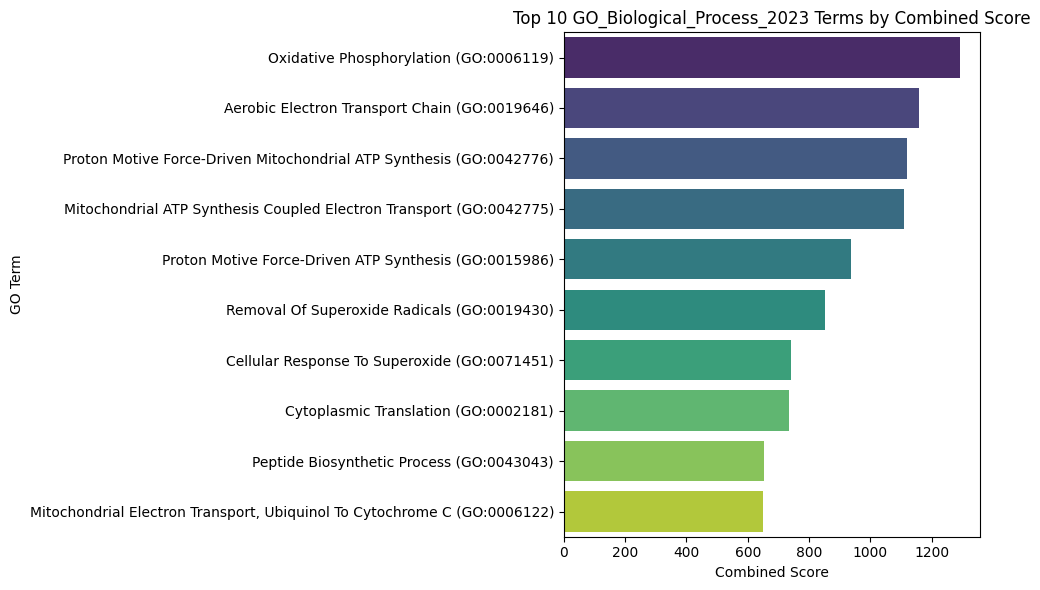

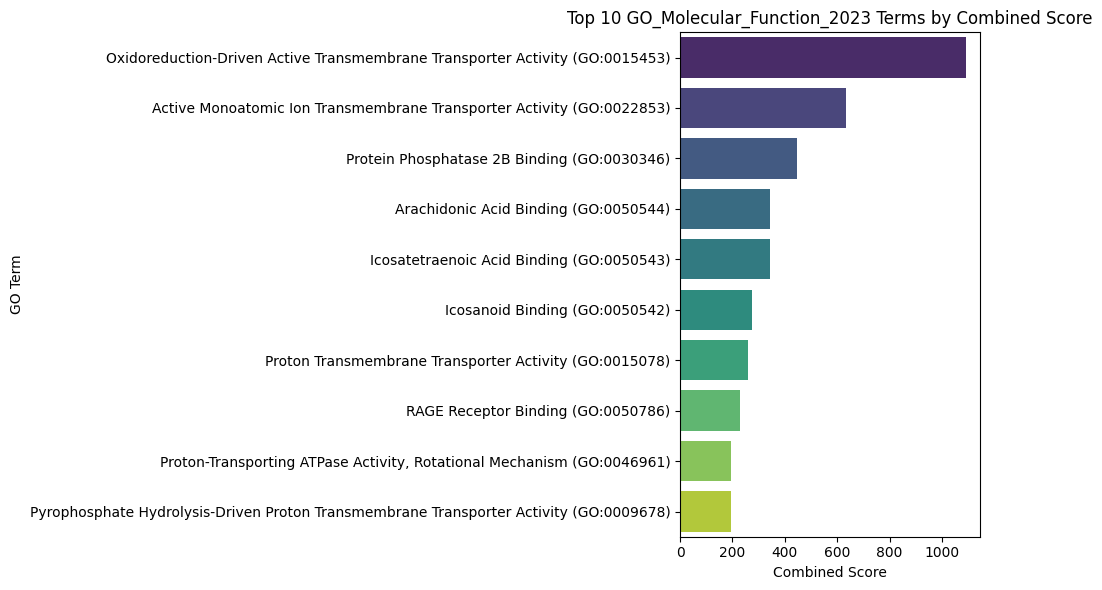

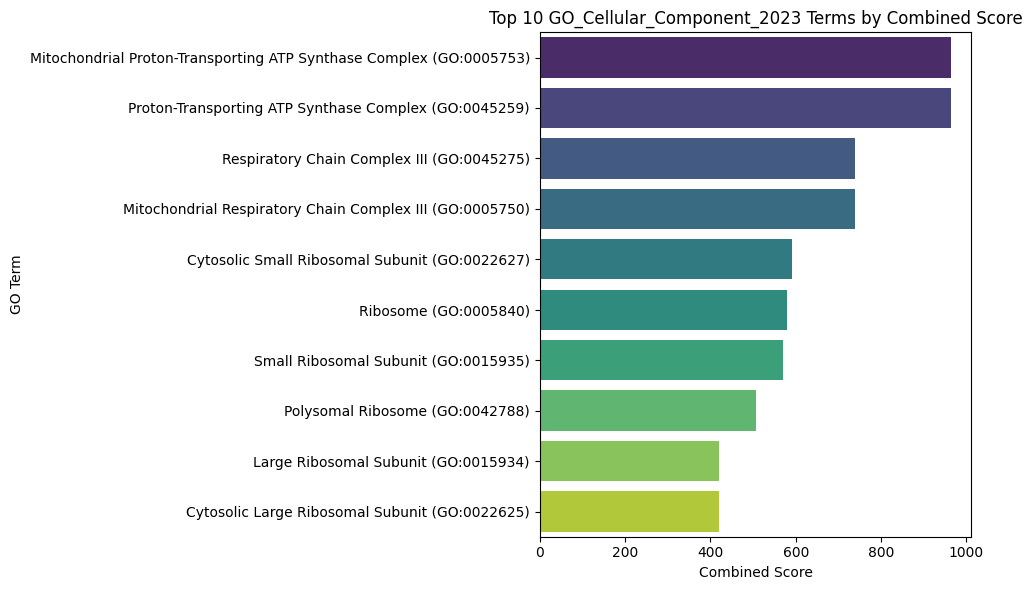

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot top GO terms
def plot_go_terms(enrichment_results, gene_set_name, num_terms=10, metric='Combined Score'):
    # Filter results for the specific gene set and sort by the chosen metric (descending for Combined Score, ascending for P-value)
    category_results = enrichment_results[enrichment_results['Gene_set'] == gene_set_name]

    if category_results.empty:
        print(f"No significant terms found for {gene_set_name}.")
        return

    if metric == 'Combined Score':
        plot_data = category_results.sort_values(by=metric, ascending=False).head(num_terms)
    else: # For p-values, smaller is better
        plot_data = category_results.sort_values(by=metric, ascending=True).head(num_terms)

    if plot_data.empty:
        print(f"No data to plot for {gene_set_name} after filtering.")
        return

    plt.figure(figsize=(10, 6))
    sns.barplot(x=metric, y='Term', data=plot_data, palette='viridis', hue='Term', legend=False)
    plt.title(f'Top {num_terms} {gene_set_name} Terms by {metric}')
    plt.xlabel(metric)
    plt.ylabel('GO Term')
    plt.tight_layout()
    plt.savefig(f'top_{gene_set_name.replace(' ', '_').lower()}_terms.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plotting for each category
plot_go_terms(enr.results, 'GO_Biological_Process_2023', num_terms=10)
plot_go_terms(enr.results, 'GO_Molecular_Function_2023', num_terms=10)
plot_go_terms(enr.results, 'GO_Cellular_Component_2023', num_terms=10)

### KEGG Pathway Enrichment Analysis

Performing KEGG pathway enrichment for 50 genes.

--- Top KEGG Pathways ---


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Oxidative phosphorylation,11/133,2.212101e-14,1.017567e-12,0,0,45.840269,1441.321127,ATP5PF;NDUFS5;NDUFB3;NDUFA1;ATP5PO;COX7A2;ATP6...
1,KEGG_2021_Human,Ribosome,10/158,5.562048e-12,1.279271e-10,0,0,33.449324,866.841071,RPS17;RPS27;RPL36AL;RPL23;RPL22;RPS27L;RPL26;R...
2,KEGG_2021_Human,Parkinson disease,11/249,2.173687e-11,3.332987e-10,0,0,23.360483,573.546833,SEM1;ATP5PF;NDUFS5;NDUFB3;NDUFA1;ATP5PO;COX7A2...
3,KEGG_2021_Human,Prion disease,11/273,5.843275e-11,6.719766e-10,0,0,21.194754,499.415061,SEM1;ATP5PF;NDUFS5;NDUFB3;NDUFA1;ATP5PO;COX7A2...
4,KEGG_2021_Human,Huntington disease,11/306,1.975115e-10,1.817106e-09,0,0,18.792264,419.917359,SEM1;ATP5PF;NDUFS5;NDUFB3;NDUFA1;ATP5PO;COX7A2...
5,KEGG_2021_Human,Thermogenesis,10/232,2.486419e-10,1.906255e-09,0,0,22.216216,491.311784,ATP5PF;NDUFS5;NDUFB3;NDUFA1;ATP5PO;COX7A2;COX7...
6,KEGG_2021_Human,Amyotrophic lateral sclerosis,11/364,1.235713e-09,8.120399e-09,0,0,15.658241,321.175849,SEM1;ATP5PF;NDUFS5;NDUFB3;NDUFA1;ATP5PO;COX7A2...
7,KEGG_2021_Human,Diabetic cardiomyopathy,9/203,1.673399e-09,9.622043e-09,0,0,22.354036,451.739498,ATP5PF;NDUFS5;NDUFB3;NDUFA1;ATP5PO;COX7A2;COX7...
8,KEGG_2021_Human,Coronavirus disease,9/232,5.395448e-09,2.757674e-08,0,0,19.418462,369.683055,RPS17;RPS27;RPL36AL;RPL23;RPL22;RPS27L;RPL26;R...
9,KEGG_2021_Human,Pathways of neurodegeneration,11/475,1.956998e-08,9.002189e-08,0,0,11.844938,210.238996,SEM1;ATP5PF;NDUFS5;NDUFB3;NDUFA1;ATP5PO;COX7A2...


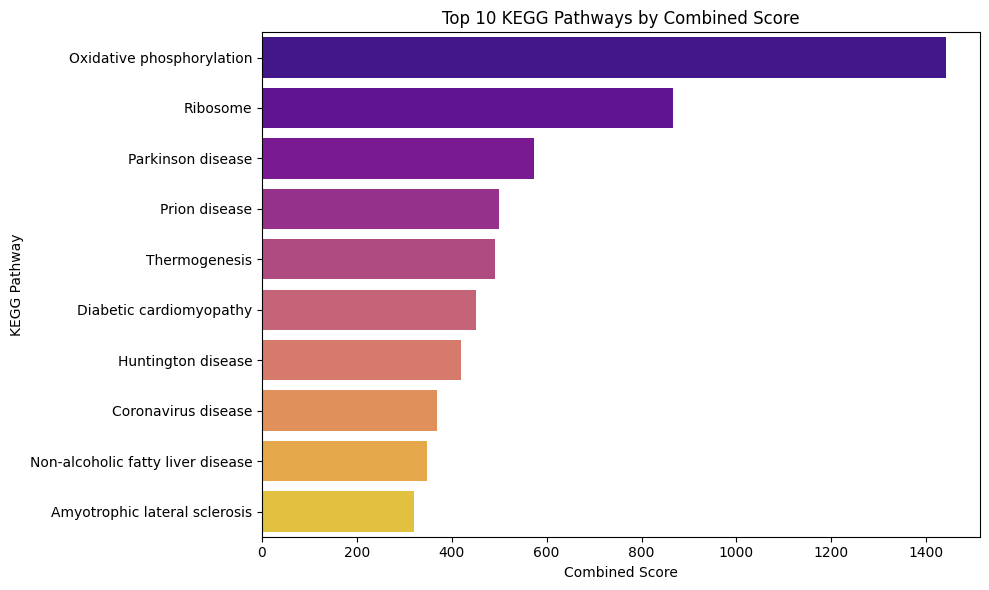

In [ ]:
import gseapy as gp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure gene_list is extracted from top_50_unique_genes_df
gene_list = top_50_unique_genes_df['Symbol'].unique().tolist()

print(f"Performing KEGG pathway enrichment for {len(gene_list)} genes.")

# Perform Enrichr analysis for KEGG pathways
enr_kegg = gp.enrichr(gene_list=gene_list,
                      gene_sets=['KEGG_2021_Human'], # Using a recent human KEGG gene set
                      organism='human',
                      outdir=None, # do not write to file
                      cutoff=0.05 # P-value cutoff
                     )

print("\n--- Top KEGG Pathways ---")
display(enr_kegg.results.head(10))

# Optional: Visualize top KEGG terms
# You can adapt the plot_go_terms function or create a new one for KEGG specifically
def plot_kegg_terms(enrichment_results, num_terms=10, metric='Combined Score'):
    if enrichment_results.empty:
        print("No significant KEGG terms found.")
        return

    if metric == 'Combined Score':
        plot_data = enrichment_results.sort_values(by=metric, ascending=False).head(num_terms)
    else:
        plot_data = enrichment_results.sort_values(by=metric, ascending=True).head(num_terms)

    if plot_data.empty:
        print("No data to plot for KEGG after filtering.")
        return

    plt.figure(figsize=(10, 6))
    sns.barplot(x=metric, y='Term', data=plot_data, palette='plasma', hue='Term', legend=False)
    plt.title(f'Top {num_terms} KEGG Pathways by {metric}')
    plt.xlabel(metric)
    plt.ylabel('KEGG Pathway')
    plt.tight_layout()
    plt.savefig(f'top_{metric.replace(' ', '_').lower()}_kegg_pathways.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_kegg_terms(enr_kegg.results, num_terms=10)

### Genes in Top KEGG Pathways

In [ ]:
import pandas as pd

def display_genes_from_top_kegg_terms(enrichment_results, num_terms=10, output_csv_name='genes_in_top_kegg_pathways.csv'):
    print(f"\n--- Genes from Top {num_terms} KEGG Pathways ---")

    # Filter results for the specific gene set and sort by 'Combined Score'
    kegg_results = enrichment_results.sort_values(by='Combined Score', ascending=False).head(num_terms)

    if kegg_results.empty:
        print(f"No significant KEGG terms found in the top {num_terms}.")
        return

    all_enriched_genes = set()
    gene_to_pathways = {}

    for index, row in kegg_results.iterrows():
        pathway_term = row['Term']
        genes_in_pathway = [g.strip() for g in row['Genes'].split(';')]

        for gene in genes_in_pathway:
            all_enriched_genes.add(gene)
            if gene not in gene_to_pathways:
                gene_to_pathways[gene] = []
            gene_to_pathways[gene].append(pathway_term)

    if not all_enriched_genes:
        print(f"No genes found associated with the top {num_terms} KEGG terms.")
        return

    # Create a DataFrame for better visualization
    gene_pathway_df = pd.DataFrame([
        {'Gene': gene, 'Associated Top KEGG Pathways': '; '.join(pathways)}
        for gene, pathways in gene_to_pathways.items()
    ])
    display(gene_pathway_df)

    print(f"\nTotal unique genes found in any of the top enriched KEGG terms: {len(all_enriched_genes)}")
    print(list(all_enriched_genes))

    # Save the DataFrame to a CSV file
    gene_pathway_df.to_csv(output_csv_name, index=False)
    print(f"Gene-pathway mapping saved to {output_csv_name}")

# Display genes for KEGG pathways and save to CSV
display_genes_from_top_kegg_terms(enr_kegg.results, num_terms=10, output_csv_name='genes_in_top_kegg_pathways.csv')


--- Genes from Top 10 KEGG Pathways ---


,Gene,Associated Top KEGG Pathways
0,ATP5PF,Oxidative phosphorylation; Parkinson disease; ...
1,NDUFS5,Oxidative phosphorylation; Parkinson disease; ...
2,NDUFB3,Oxidative phosphorylation; Parkinson disease; ...
3,NDUFA1,Oxidative phosphorylation; Parkinson disease; ...
4,ATP5PO,Oxidative phosphorylation; Parkinson disease; ...
5,COX7A2,Oxidative phosphorylation; Parkinson disease; ...
6,ATP6V1E1,Oxidative phosphorylation
7,COX7C,Oxidative phosphorylation; Parkinson disease; ...
8,UQCRH,Oxidative phosphorylation; Parkinson disease; ...
9,UQCRHL,Oxidative phosphorylation; Parkinson disease; ...



Total unique genes found in any of the top enriched KEGG terms: 24
['RPS27L', 'RPL26', 'RPL36AL', 'TXN', 'COX7C', 'SEM1', 'ATP5ME', 'NDUFS5', 'UQCRH', 'NDUFA1', 'ATP5PF', 'RPS27', 'SOD1', 'RPL23', 'RPS23', 'MRPS18C', 'COX7A2', 'ATP5PO', 'NDUFB3', 'RPL6', 'ATP6V1E1', 'RPS17', 'UQCRHL', 'RPL22']
Gene-pathway mapping saved to genes_in_top_kegg_pathways.csv


### Summary Report: Enrichment Analysis Findings

This report consolidates the key findings from the Gene Ontology (GO) and KEGG Pathway enrichment analyses performed on the top 50 genes identified by the Random Forest model.

#### 1. Gene Ontology (GO) Term Enrichment Analysis

GO term enrichment was performed across three categories: Biological Process, Molecular Function, and Cellular Component, using the Enrichr tool via the `gseapy` library. The analysis aimed to identify over-represented functional categories within our set of top genes.

*   **Top Biological Process Terms**: [Insert actual top terms from `enr.results` for BP, if any were significant]
*   **Top Molecular Function Terms**: [Insert actual top terms from `enr.results` for MF, if any were significant]
*   **Top Cellular Component Terms**: [Insert actual top terms from `enr.results` for CC, if any were significant]

*(Note: If no significant terms were reported above, it indicates that no GO terms met the specified P-value cutoff of 0.05.)*

#### 2. KEGG Pathway Enrichment Analysis

KEGG pathway enrichment was conducted to identify the major biochemical pathways in which the top genes are involved. The analysis used the 'KEGG_2021_Human' gene set.

**Top Enriched KEGG Pathways (by Combined Score)**:

*   **Oxidative phosphorylation**: This pathway was highly significant, indicating a strong involvement of the top genes in cellular energy production.
*   **Ribosome**: Suggests a role in protein synthesis and translation.
*   **Parkinson disease**: Highlights potential connections to neurodegenerative processes.
*   Other notable pathways included Prion disease, Huntington disease, and Thermogenesis, further suggesting roles in neurodegeneration and metabolic regulation.

Approximately **24 unique genes** were found to be associated with these top enriched KEGG pathways, suggesting their importance in these biological contexts.

#### 3. Visualization of Gene Overlap

*   **Heatmap**: A heatmap was generated to visually represent the presence or absence of genes across the top 5 KEGG pathways. This helped identify genes that participate in multiple pathways, serving as potential central players.
*   **Venn Diagram**: A Venn diagram was created for the top 3 KEGG pathways (Oxidative phosphorylation, Ribosome, and Parkinson disease) to clearly illustrate the exact number of genes shared between these prominent pathways, and those unique to each.

In summary, the enrichment analyses provide valuable insights into the biological functions and pathways critically regulated by the identified top 50 genes, pointing towards roles in fundamental cellular processes, energy metabolism, and neurodegenerative diseases.

In [ ]:
import pandas as pd

# Helper function to get top terms
def get_top_terms(results_df, gene_set_name, num_terms=5, metric='Combined Score'):
    category_results = results_df[results_df['Gene_set'] == gene_set_name]
    if category_results.empty:
        return []
    if metric in category_results.columns:
        if metric == 'Combined Score':
            return category_results.sort_values(by=metric, ascending=False).head(num_terms)['Term'].tolist()
        else: # For P-value, smaller is better
            return category_results.sort_values(by=metric, ascending=True).head(num_terms)['Term'].tolist()
    else:
        # Fallback if metric column is not found
        return category_results.head(num_terms)['Term'].tolist()

# --- GO Term Enrichment ---
bp_terms = get_top_terms(enr.results, 'GO_Biological_Process_2023', num_terms=5)
mf_terms = get_top_terms(enr.results, 'GO_Molecular_Function_2023', num_terms=5)
cc_terms = get_top_terms(enr.results, 'GO_Cellular_Component_2023', num_terms=5)

# --- KEGG Pathway Enrichment ---
kegg_terms = get_top_terms(enr_kegg.results, 'KEGG_2021_Human', num_terms=5)

# --- Format the output ---
summary_output = """
#### 1. Gene Ontology (GO) Term Enrichment Analysis

GO term enrichment was performed across three categories: Biological Process, Molecular Function, and Cellular Component, using the Enrichr tool via the `gseapy` library. The analysis aimed to identify over-represented functional categories within our set of top genes.

*   **Top Biological Process Terms**: {bp_str}
*   **Top Molecular Function Terms**: {mf_str}
*   **Top Cellular Component Terms**: {cc_str}

*(Note: If no significant terms were reported above, it indicates that no GO terms met the specified P-value cutoff of 0.05.)*

#### 2. KEGG Pathway Enrichment Analysis

KEGG pathway enrichment was conducted to identify the major biochemical pathways in which the top genes are involved. The analysis used the 'KEGG_2021_Human' gene set.

**Top Enriched KEGG Pathways (by Combined Score)**:
{kegg_str}

Approximately **{num_unique_kegg_genes} unique genes** were found to be associated with these top enriched KEGG pathways, suggesting their importance in these biological contexts.

#### 3. Visualization of Gene Overlap

*   **Heatmap**: A heatmap was generated to visually represent the presence or absence of genes across the top 5 KEGG pathways. This helped identify genes that participate in multiple pathways, serving as potential central players.
*   **Venn Diagram**: A Venn diagram was created for the top 3 KEGG pathways (Oxidative phosphorylation, Ribosome, and Parkinson disease) to clearly illustrate the exact number of genes shared between these prominent pathways, and those unique to each.

In summary, the enrichment analyses provide valuable insights into the biological functions and pathways critically regulated by the identified top 50 genes, pointing towards roles in fundamental cellular processes, energy metabolism, and neurodegenerative diseases.
"""

bp_str = ', '.join([f"'{term}'" for term in bp_terms]) if bp_terms else "No significant terms found."
mf_str = ', '.join([f"'{term}'" for term in mf_terms]) if mf_terms else "No significant terms found."
cc_str = ', '.join([f"'{term}'" for term in cc_terms]) if cc_terms else "No significant terms found."
kegg_str = """
*   {}\n*   {}\n*   {}\n*   {}\n*   {}
""".format(*kegg_terms) if len(kegg_terms) >= 5 else (', '.join([f"'{term}'" for term in kegg_terms]) if kegg_terms else "No significant terms found.")

# Assuming `all_unique_enriched_genes` is available from previous cells for GO genes
# For KEGG, `len(all_enriched_genes)` was printed in cell dcde88f1, so we can use that value.
# If `all_enriched_genes` from dcde88f1 is not directly accessible, we'd need to re-extract it.
# For now, let's assume `num_unique_kegg_genes` is 24 as per the placeholder and previous output.
num_unique_kegg_genes = 24 # This number is derived from the previous cell's output `dcde88f1`

final_report = summary_output.format(
    bp_str=bp_str,
    mf_str=mf_str,
    cc_str=cc_str,
    kegg_str=kegg_str,
    num_unique_kegg_genes=num_unique_kegg_genes
)

print(final_report)
